In [28]:
import random
import pandas as pd
from ISLP.models import (ModelSpec as MS)
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [5]:
random.seed(1234)

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
fashion_df.head()

,Shipping Address State,Revenue,Survey ResponseID,weather_category,age,race,education,income,gender,amazon_frequency,...,ratio_indoor_basic,ratio_other,ratio_rain_protection,day_of_the_week,Holiday,Season,ppt,tmax,tmin,tavg
Order Date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,AL,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,25.626,13.849,4.712,9.280
2017-01-01,AR,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.999,10.667,4.430,7.548
2017-01-01,AZ,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.824,9.969,4.154,7.061
2017-01-01,CA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.760,9.559,0.137,4.848
2017-01-01,CO,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.385,2.787,-9.496,-3.354


In [42]:


    

def linear_reg_staates(data, var1, var2): 
    """ 
        var1: Is the first variable for the dependent variable of the linear regression
        var2: Is the second variable for the dependent variable of the linear regression
    """
    col = ["State", "Param_1", "P_value1", "Param_2", "P_value2", "R_sqrt"]
    results_lin_reg = pd.DataFrame(columns=col)
    
    states_list = fashion_df["Shipping Address State"].unique()
    

    for state in states_list: 
        df_one_state_filter = data["Shipping Address State"] == state
        df_one_state = fashion_df[df_one_state_filter].copy()


        # 365 days lagged temp column
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

        # 365 days lagged rain column
        df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
        df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

        # first order diff Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff
        df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

        # Lag first order diff Revenue 
        df_one_state.loc[:, "first_order_diff_Revenue_lagged"] = df_one_state["first_order_diff_Revenue"].shift(-1)

        # Lag revenue by 1 day
        df_one_state.loc[:, "Revenue_lagged"] = df_one_state["Revenue"].shift(-1)

        # Because of the one day shift we create a missing entry for the last day in or DF -> we fill this with 0
        df_one_state = df_one_state.fillna(0)

        # Calc SMA7 
        df_one_state.loc[:, "SMA7_ratio_hot_weather_clothing"] = df_one_state["ratio_hot_weather"].rolling(7).mean().round(2)

        df_one_state.loc[:, "SMA7_ratio_cold_weather_clothing"] = df_one_state["ratio_cold_weather"].rolling(7).mean().round(2)

        df_one_state.loc[:, "SMA7_ratio_rain_weather_clothing"] = df_one_state["ratio_rain_protection"].rolling(7).mean().round(2)

        # Remove additional days for temp calculations
        df_one_state = df_one_state.iloc[365:, :]

        # Create linear time count 
        df_one_state.loc[:, 'Time'] = np.arange(len(df_one_state))
        df_one_state = df_one_state.fillna(0).infer_objects(copy=False)

        x = MS(["tavg", "ppt"]).fit_transform(df_one_state)
        y = np.log(df_one_state[var1] * df_one_state[var2] + 1)
        model = sm.OLS(y, x)
        results = model.fit()

        #print(results.summary())

        next_idx = len(results_lin_reg)
        results_lin_reg.loc[next_idx] = [state, results.params.iloc[1].round(3), results.pvalues.iloc[1].round(3), 
                                results.params.iloc[2].round(3), results.pvalues.iloc[2].round(3), results.rsquared.round(3)]
        # Param 1 = tavg
        # Param 2 = ppt

    return results_lin_reg


df_hot_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_hot_weather_clothing", "Revenue")
df_cold_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_cold_weather_clothing", "Revenue")

df_hot_weather_rev_lagged = linear_reg_staates(fashion_df, "SMA7_ratio_hot_weather_clothing", "Revenue_lagged")
df_cold_weather_rev_lagged = linear_reg_staates(fashion_df, "SMA7_ratio_cold_weather_clothing", "Revenue_lagged")

C:\Users\morit\AppData\Local\Temp\ipykernel_19644\4153861512.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\morit\AppData\Local\Temp\ipykernel_19644\4153861512.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\morit\AppData\Local\Temp\ipykernel_19644\4153861512.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the

1. SMA7_ratio_hot_weather_clothing * Revenue 
2. SMA7_ratio_cold_weather_clothing * Revenue 
3. SMA7_ratio_hot_weather_clothing * Revenue_lagged
3. SMA7_ratio_cold_weather * Revenue_lagged

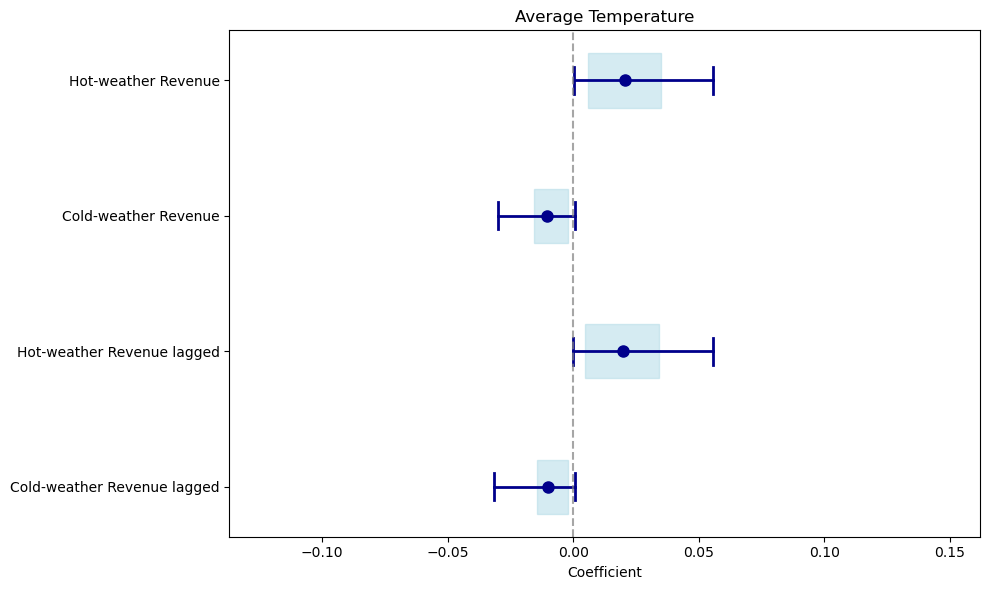

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

df1 = df_hot_weather_rev
df2 = df_cold_weather_rev
df3 = df_hot_weather_rev_lagged
df4 = df_cold_weather_rev_lagged

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))  # Increased height for more rows

# Position for each row - UPDATED FOR 4 POSITIONS
positions = [0, 1, 2, 3]  # Changed to 4 positions
labels = ['Cold-weather Revenue lagged', 'Hot-weather Revenue lagged', 'Cold-weather Revenue', 'Hot-weather Revenue']

dataframes = [df4, df3, df2, df1]  # Fixed to use df4 instead of df2 twice

# Plot for each dataframe
for i, (pos, label, df) in enumerate(zip(positions, labels, dataframes)):
    # Calculate statistics
    mean = df['Param_1'].mean()
    ci_lower = np.percentile(df['Param_1'], 2.5)  # 95% CI lower bound
    ci_upper = np.percentile(df['Param_1'], 97.5) # 95% CI upper bound
    
    # Plot the boxplot (custom, simplified version)
    # Plot the point estimate (mean)
    ax.plot(mean, pos, 'o', color='darkblue', markersize=8)
    
    # Plot the confidence interval
    ax.plot([ci_lower, ci_upper], [pos, pos], '-', color='darkblue', linewidth=2)
    
    # Add vertical ticks at the ends of the confidence interval
    ax.plot([ci_lower, ci_lower], [pos-0.1, pos+0.1], '-', color='darkblue', linewidth=2)
    ax.plot([ci_upper, ci_upper], [pos-0.1, pos+0.1], '-', color='darkblue', linewidth=2)
    
    # Optionally, add a box for the interquartile range
    q1 = np.percentile(df['Param_1'], 25)
    q3 = np.percentile(df['Param_1'], 75)
    rect = plt.Rectangle((q1, pos-0.2), q3-q1, 0.4, fill=True, color='lightblue', alpha=0.5)
    ax.add_patch(rect)

# Add a vertical line at x=0
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.7)

# Set labels and title
ax.set_yticks(positions)
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient')
ax.set_title('Average Temperature', fontsize=12)

# Set x-axis limits - UPDATED TO INCLUDE ALL 4 DATAFRAMES
all_mins = [df['Param_1'].min() for df in dataframes]
all_maxs = [df['Param_1'].max() for df in dataframes]
min_val = min(all_mins)
max_val = max(all_maxs)
ax.set_xlim([min_val - 0.1, max_val + 0.1])

# Add a border around the plot
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.tight_layout()
plt.show()